In [119]:
import numpy as np
import pandas as pd 
import os
data_location = '/kaggle/input/competitions/ieee-fraud-detection/'
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


# Cleaning

In [120]:
df_trans = pd.read_csv(f'{data_location}/train_transaction.csv')
df_id = pd.read_csv(f'{data_location}/train_identity.csv')

In [121]:
df_trans.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [122]:
df_id.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [ ]:
df = pd.merge(
    df_trans, 
    df_id, 
    on='TransactionID', 
    how='left'
)

In [ ]:
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage of dataframe is {:.2f} MB'.format(start_mem))
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print('Memory usage after optimization is: {:.2f} MB'.format(end_mem))
    print('Decreased by {:.1f}%'.format(100 * (start_mem - end_mem) / start_mem))
    
    return df

In [ ]:
df = reduce_mem_usage(df)

Memory usage of dataframe is 1955.37 MB


/tmp/ipykernel_57/505373522.py:24: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/505373522.py:24: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/505373522.py:24: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/505373522.py:24: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/505373522.py:24: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/505373522.py:24: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/505373522.py:24: RuntimeWarning: overflow enco

Memory usage after optimization is: 525.55 MB
Decreased by 73.1%


In [127]:
df.head()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [128]:
df.shape

(590540, 434)

In [ ]:
from sklearn.model_selection import train_test_split
import gc

X = df.drop(columns=['isFraud'])
y = df['isFraud']

ids = X.pop('TransactionID')

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

del X, y, df
gc.collect()

9

In [130]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((472432, 432), (118108, 432), (472432,), (118108,))

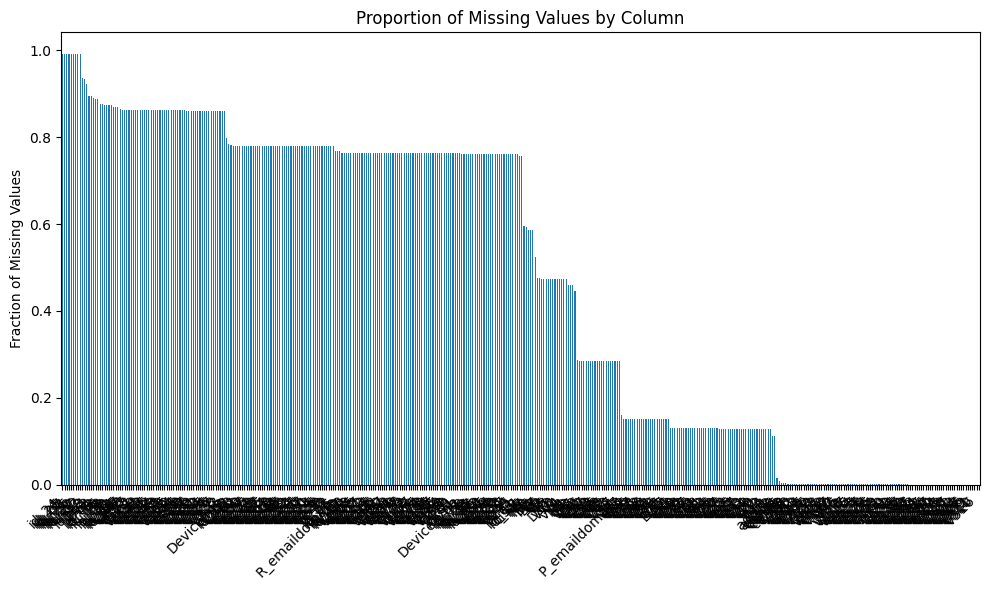

In [131]:
import matplotlib.pyplot as plt

null_ratio = x_train.isna().sum() / x_train.shape[0]
null_ratio = null_ratio[null_ratio > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
null_ratio.plot(kind='bar')
plt.title('Proportion of Missing Values by Column')
plt.ylabel('Fraction of Missing Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
threshold = 0.8

high_nan_cols = null_ratio[null_ratio > threshold].index.tolist()

print(f"num of high_na {len(high_nan_cols)} columns with > {threshold*100}% missing values.")

num of high_na 74 columns with > 80.0% missing values.


In [ ]:
remaining_cols = [col for col in x_train.columns if col not in high_nan_cols]

cat_cols = x_train[remaining_cols].select_dtypes(include=['object', 'category']).columns.tolist()

num_cols = x_train[remaining_cols].select_dtypes(exclude=['object', 'category']).columns.tolist()

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numerical columns ({len(num_cols)}): {num_cols}")

Categorical columns (26): ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_28', 'id_29', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']
Numerical columns (332): ['TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D10', 'D11', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69'

In [134]:
num_uniques = x_train[cat_cols].nunique()

In [135]:
threshold = 3

woe_columns = list(num_uniques[num_uniques > 3].index)
one_hot_columns = list(num_uniques[num_uniques <= 3].index)


In [136]:
print(len(one_hot_columns))

19


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline

ohe_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ohe",    OneHotEncoder(handle_unknown="ignore"))
])

num_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("drop_high_nan", "drop",                               high_nan_cols),
        ("num_impute",    num_pipeline,                         num_cols),
        ("ohe",           ohe_pipeline,                        one_hot_columns)
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)


In [138]:
pip install dagshub

Note: you may need to restart the kernel to use updated packages.


In [139]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.


In [140]:
import dagshub

In [141]:
import mlflow

In [142]:
import dagshub
dagshub.init(repo_owner='ikvas22', repo_name='ikvas22_ML_Assignment2', mlflow=True)

Initialized MLflow to track repo "ikvas22/ikvas22_ML_Assignment2"

Repository ikvas22/ikvas22_ML_Assignment2 initialized!

In [143]:
mlflow.set_experiment("Random_Forest_Training")

<Experiment: artifact_location='mlflow-artifacts:/ecb36f3fbdc943b4ab7b2bcde1fc416d', creation_time=1777735694311, experiment_id='1', last_update_time=1777735694311, lifecycle_stage='active', name='Random_Forest_Training', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [ ]:
import skops.io as sio

with mlflow.start_run(run_name="Random_Forest_Cleaning_Lower_IV_Threshold"):
    mlflow.log_param("high_nan_cols",       str(high_nan_cols))
    mlflow.log_param("num_impute_strategy", "median")
    mlflow.log_param("cat_impute_strategy", "most_frequent")
    mlflow.log_param("woe_cols",            str(woe_columns))
    mlflow.log_param("ohe_cols",            str(one_hot_columns))

    sio.dump(preprocessor, "cleaning_pipeline.skops")
    mlflow.log_artifact("cleaning_pipeline.skops")

    preprocessing_run_id = mlflow.active_run().info.run_id
    print(f"Preprocessing run id: {preprocessing_run_id}")

Preprocessing run id: 01739eeff90344f1974566ccf87fb64a
🏃 View run Random_Forest_Cleaning_Lower_IV_Threshold at: https://dagshub.com/ikvas22/ikvas22_ML_Assignment2.mlflow/#/experiments/1/runs/01739eeff90344f1974566ccf87fb64a
🧪 View experiment at: https://dagshub.com/ikvas22/ikvas22_ML_Assignment2.mlflow/#/experiments/1


# Feature Engineering

In [145]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

class RFESelector(BaseEstimator, TransformerMixin):
    def __init__(self, n_features_to_select=50):
        self.n_features_to_select = n_features_to_select
        self.selected_features_ = None
        self.rfe_ = None

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        self.feature_names_ = list(X.columns)
        
        estimator = RandomForestClassifier(
            n_estimators=100,
            max_depth=5,
            n_jobs=-1,
            random_state=42
        ) 
        self.rfe_ = RFE(estimator=estimator, n_features_to_select=self.n_features_to_select)
        self.rfe_.fit(X, y)
        
        self.selected_features_ = [
            f for f, s in zip(self.feature_names_, self.rfe_.support_) if s
        ]
        print(f"RFE selected features: {self.selected_features_}")
        return self

    def transform(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        X.columns = self.feature_names_
        return X[self.selected_features_]

In [ ]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.85):
        self.threshold = threshold
        self.features_to_drop_ = None
        self.selected_features_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X).reset_index(drop=True)
        
        corr_matrix = X.corr().abs()
        
        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        self.features_to_drop_ = set()
        for col in upper.columns:
            if any(upper[col] > self.threshold):
                partners = upper.index[upper[col] > self.threshold].tolist()
                for partner in partners:
                    if corr_matrix[col].mean() >= corr_matrix[partner].mean():
                        self.features_to_drop_.add(col)
                    else:
                        self.features_to_drop_.add(partner)

        self.selected_features_ = [
            col for col in X.columns if col not in self.features_to_drop_
        ]

        print(f"Correlation filter dropped: {self.features_to_drop_}")
        print(f"Correlation filter kept:    {self.selected_features_}")
        return self

    def transform(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        return X[self.selected_features_]

In [147]:
class IVValidator(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.05):
        # IV interpretation:
        # < 0.02  → useless
        # 0.02–0.1 → weak
        # 0.1–0.3 → medium
        # 0.3+    → strong
        self.threshold = threshold
        self.iv_scores_ = {}
        self.selected_features_ = None

    def _compute_iv(self, X, y, col):
        df = pd.DataFrame({"col": X[col], "target": y})
        total_events = y.sum()
        total_non_events = (1 - y).sum()

        iv = 0
        for val, group in df.groupby("col"):
            events = group["target"].sum()
            non_events = (1 - group["target"]).sum()

            dist_e  = (events + 0.5) / (total_events + 0.5)
            dist_ne = (non_events + 0.5) / (total_non_events + 0.5)

            woe = np.log(dist_e / dist_ne)
            iv += (dist_e - dist_ne) * woe
        return iv

    def fit(self, X, y):
        X = pd.DataFrame(X).reset_index(drop=True)
        y = pd.Series(y).reset_index(drop=True)

        self.iv_scores_ = {}
        for col in X.columns:
            self.iv_scores_[col] = self._compute_iv(X, y, col)

        print("\nIV Scores:")
        for col, iv in sorted(self.iv_scores_.items(), key=lambda x: -x[1]):
            label = (
                "useless" if iv < 0.02 else
                "weak"    if iv < 0.1  else
                "medium"  if iv < 0.3  else
                "strong"
            )
            print(f"  {col}: {iv:.4f} ({label})")

        self.selected_features_ = [
            col for col, iv in self.iv_scores_.items() if iv >= self.threshold
        ]
        print(f"\nIV kept features: {self.selected_features_}")
        return self

    def transform(self, X):
        X = pd.DataFrame(X).reset_index(drop=True)
        return X[self.selected_features_]

In [148]:
class ColumnNameRestorer(BaseEstimator, TransformerMixin):
    def __init__(self, column_transformer):
        self.column_transformer = column_transformer

    def fit(self, X, y=None):
        self.feature_names_ = self.column_transformer.get_feature_names_out()
        return self

    def transform(self, X):
        return pd.DataFrame(X, columns=self.feature_names_)

In [ ]:
class WOEEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols
        self.woe_map = {}

    def fit(self, X, y):
        X = X.copy()
        for col in self.cols:
            stats = pd.DataFrame({"col": X[col], "target": y})
            total_events = y.sum()           
            total_non_events = (1 - y).sum()

            woe_dict = {}
            for val, group in stats.groupby("col"):
                events = group["target"].sum()
                non_events = (1 - group["target"]).sum()

                dist_events = (events + 0.5) / (total_events + 0.5)
                dist_non_events = (non_events + 0.5) / (total_non_events + 0.5)

                woe_dict[val] = np.log(dist_events / dist_non_events)
            self.woe_map[col] = woe_dict
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols:
            X[col] = X[col].map(self.woe_map[col]).fillna(0)
        return X

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class Float32Converter(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X_transformed = X.copy()
        
        for col in X_transformed.columns:
            if X_transformed[col].dtype == 'object':
                X_transformed[col] = X_transformed[col].astype('float32')
                
        return X_transformed

In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

feature_pipeline = Pipeline([
    ("col_restorer", ColumnNameRestorer(preprocessor)),
    ("woe", WOEEncoder(cols=woe_columns)),
    ("iv", IVValidator(threshold=0.05)),
    ("corr_filter", CorrelationFilter(threshold=0.85)),
    ("type_converter", Float32Converter())
])

("undersampler", RandomUnderSampler(sampling_strategy='majority', random_state=42)),

(('undersampler',
  RandomUnderSampler(random_state=42, sampling_strategy='majority')),)

In [ ]:
with mlflow.start_run(run_name="Random_Forest_Feature_Engineering_Lower_IV_Threshold"):
    mlflow.log_param("corr_threshold",      0.85)
    mlflow.log_param("iv_threshold",        0.05)
    mlflow.log_param("sampling_strategy", 'majority_undersampling')

    sio.dump(feature_pipeline, "features_pipeline.skops")
    mlflow.log_artifact("features_pipeline.skops")

    feature_run_id = mlflow.active_run().info.run_id
    print(f"Preprocessing run id: {feature_run_id}")

Preprocessing run id: d51f50184e2046908f5282a8a0c2b437
🏃 View run Random_Forest_Feature_Engineering_Lower_IV_Threshold at: https://dagshub.com/ikvas22/ikvas22_ML_Assignment2.mlflow/#/experiments/1/runs/d51f50184e2046908f5282a8a0c2b437
🧪 View experiment at: https://dagshub.com/ikvas22/ikvas22_ML_Assignment2.mlflow/#/experiments/1


# Training

In [153]:
%%time
full_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("feature_eng", feature_pipeline)
])

full_pipeline.fit(x_train, y_train)
x_train_base = full_pipeline.transform(x_train)
x_test.columns = x_test.columns.str.replace('-', '_')
x_test_base = full_pipeline.transform(x_test)

rus = RandomUnderSampler(sampling_strategy='majority', random_state=42)
x_train_ready, y_train_ready = rus.fit_resample(x_train_base, y_train)


IV Scores:
  TransactionDT: 33.1980 (strong)
  id_02: 8.5076 (strong)
  V307: 2.8171 (strong)
  V127: 1.9987 (strong)
  V264: 1.9980 (strong)
  V308: 1.9837 (strong)
  V203: 1.9451 (strong)
  card1: 1.9135 (strong)
  V265: 1.8652 (strong)
  V204: 1.8028 (strong)
  TransactionAmt: 1.7414 (strong)
  V263: 1.6910 (strong)
  V317: 1.6656 (strong)
  V202: 1.6013 (strong)
  V274: 1.5969 (strong)
  V212: 1.5176 (strong)
  V128: 1.4816 (strong)
  V213: 1.4493 (strong)
  V306: 1.3813 (strong)
  V318: 1.3295 (strong)
  V211: 1.3270 (strong)
  V275: 1.2569 (strong)
  V133: 1.2537 (strong)
  V273: 1.1733 (strong)
  V126: 1.1628 (strong)
  V134: 1.0925 (strong)
  V258: 0.9946 (strong)
  C4: 0.9773 (strong)
  V316: 0.9724 (strong)
  C12: 0.9721 (strong)
  C8: 0.9631 (strong)
  V257: 0.9214 (strong)
  V201: 0.9123 (strong)
  card2: 0.9123 (strong)
  V132: 0.9107 (strong)
  C7: 0.8797 (strong)
  V200: 0.8554 (strong)
  V246: 0.8412 (strong)
  V259: 0.8207 (strong)
  C10: 0.8042 (strong)
  V243: 0.785

/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py:62: FutureWarning: This Pipeline inst

CPU times: user 12min 47s, sys: 32.4 s, total: 13min 19s
Wall time: 13min 16s


In [154]:
x_train_ready.shape

(32842, 128)

In [155]:
x_train_ready.head()

,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,dist1,C5,C7,...,M6_F,M8_F,id_38_T,DeviceType_desktop,ProductCD,card6,P_emaildomain,R_emaildomain,id_31,DeviceInfo
408702,0.146500,-0.341296,-0.602340,-1.606398,-0.281587,0.6446,1.554685,-0.184159,-0.216156,-0.045973,...,0.0,1.0,0.0,1.0,-0.00067,-0.001112,-0.019947,0.000000,0.0,0.0
331435,-0.603229,-0.462244,-0.082005,-0.264944,-0.281587,0.6446,-0.206345,-0.184159,-0.177317,-0.045973,...,0.0,1.0,0.0,1.0,-0.00067,-0.001112,-0.012424,0.000000,0.0,0.0
1833,-0.946460,-0.506499,-1.560745,1.165940,2.808078,0.6446,0.075003,-0.184159,-0.216156,-0.029813,...,1.0,1.0,0.0,1.0,0.00380,0.024042,-0.019947,0.003604,0.0,0.0
67701,1.764682,-0.076494,0.570201,0.814607,-0.281587,0.6446,0.345931,-0.180050,-0.216156,-0.045973,...,0.0,1.0,0.0,1.0,-0.00067,-0.001112,-0.596858,0.000000,0.0,0.0
345456,1.446825,-0.513085,-0.082005,-0.264944,-0.281587,0.6446,-0.914924,-0.184159,-0.177317,-0.045973,...,1.0,1.0,0.0,1.0,-0.00067,-0.001112,-0.019947,0.000000,0.0,0.0


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import GridSearchCV
import gc

param_grid = {
    'max_depth': [5, 10, 20],
    'n_estimators': [300, 500, 1000],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

print("Setting up Grid Search...")
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=1,
    class_weight='balanced'
)

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2
)

print("Starting Grid Search... this will take some time!")
grid_search.fit(x_train_ready, y_train_ready)

print(f"Best ROC-AUC Score from CV: {grid_search.best_score_:.5f}")
print("Best Parameters:")
for key, value in grid_search.best_params_.items():
    print(f"   - {key}: {value}")

best_rf_model = grid_search.best_estimator_

y_pred_proba = best_rf_model.predict_proba(x_test_base)[:, 1]

final_roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"Final Test ROC-AUC with Best Model: {final_roc_auc:.5f}")

Setting up Grid Search...
Starting Grid Search... this will take some time!
Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=300; total time=   7.8s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=500; total time=  13.2s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=1000; total time=  25.9s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=5, n_estimators=1000; total time=  25.8s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=10, n_estimators=500; total time=  13.0s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=10, n_estimators=1000; total time=  25.8s
[CV] END max_depth=5, max_features=log2, min_samples_split=2, n_estimators=500; total time=   9.5s
[CV] END max_depth=5, max_features=log2, min_samples_split=5, n_estimators=300; total time=   5.6s
[CV] END max_depth=5, max_features=log2, min_samples_split=5, n_e

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=300; total time=   7.9s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=2, n_estimators=500; total time=  13.2s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=5, n_estimators=300; total time=   7.7s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=5, n_estimators=300; total time=   7.8s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=5, n_estimators=500; total time=  13.0s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=5, n_estimators=1000; total time=  25.8s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=10, n_estimators=500; total time=  12.8s
[CV] END max_depth=5, max_features=sqrt, min_samples_split=10, n_estimators=1000; total time=  25.8s
[CV] END max_depth=5, max_features=log2, min_samples_split=2, n_estimators=1000; total time=  18.7s
[CV] END max_depth=5, max_features=log2, min_samples_split=5, n_estimators=500; total time=   9.5s
[CV] 

In [ ]:
import skops.io as sio
final_model = best_rf_model 

with mlflow.start_run(run_name="Random_Forest_Model_Training_Lower_IV_Threshold"):
    
    mlflow.log_params(final_model.get_params())
    
    mlflow.log_metric("cv_roc_auc", grid_search.best_score_)
    mlflow.log_metric("test_roc_auc", final_roc_auc) 
    
    sio.dump(final_model, "random_forest_model.skops")
    mlflow.log_artifact("random_forest_model.skops")
    
    run_id = mlflow.active_run().info.run_id
    print(f"Model successfully logged to MLflow via skops!")
    print(f"Run ID: {run_id}")
    print(f"Test ROC-AUC: {final_roc_auc:.4f}")

🎉 Model successfully logged to MLflow via skops!
Run ID: 0f2ec36bb9d549fcbcddbd5ce71bbaaa
Test ROC-AUC: 0.9261
🏃 View run Random_Forest_Model_Training_Lower_IV_Threshold at: https://dagshub.com/ikvas22/ikvas22_ML_Assignment2.mlflow/#/experiments/1/runs/0f2ec36bb9d549fcbcddbd5ce71bbaaa
🧪 View experiment at: https://dagshub.com/ikvas22/ikvas22_ML_Assignment2.mlflow/#/experiments/1
[CV] END max_depth=20, max_features=sqrt, min_samples_split=5, n_estimators=500; total time=  42.3s
[CV] END max_depth=20, max_features=sqrt, min_samples_split=10, n_estimators=300; total time=  24.4s
[CV] END max_depth=20, max_features=sqrt, min_samples_split=10, n_estimators=300; total time=  24.5s
[CV] END max_depth=20, max_features=sqrt, min_samples_split=10, n_estimators=500; total time=  40.6s
[CV] END max_depth=20, max_features=sqrt, min_samples_split=10, n_estimators=1000; total time= 1.4min
[CV] END max_depth=20, max_features=log2, min_samples_split=2, n_estimators=500; total time=  32.4s
[CV] END max_